In [1]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [2]:
#Step 2: Load BERTopic Results
#Load patent-topic mapping
df = pd.read_csv(
    "/Users/asawaribrijeshtalathi/Downloads/AI-Driven-Medical-Devices-Intelligent-System 3/src/data/processed/cleaned_patent_data_with_citations.csv"
)
print(df.columns)
print(df.shape)

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'filing_date',
       'publication_date', 'country', 'assignee_original', 'assignee_en',
       'ipc_codes', 'cpc_codes', 'claim_count', 'independent_claim_count',
       'backward_citation_count', 'forward_citation_count', 'legal_status',
       'detected_language', 'claims_clean', 'combined_text', 'abstract_length',
       'word_count', 'claims_length_chars', 'claims_word_count',
       'claims_length', 'filing_year', 'year', 'patent_age', 'forward_norm',
       'backward_norm', 'age_norm', 'citation_influence_score'],
      dtype='object')
(18352, 35)


In [3]:
import pandas as pd

topic_df = pd.read_csv("../results/bertopic/patent_topics.csv")

print(topic_df.columns.tolist())

['patent_id', 'title', 'combined_text', 'filing_year', 'country', 'assignee_en', 'cpc_codes', 'ipc_codes', 'document_length', 'topic_text', 'topic']


In [4]:
#Load topic summary
topic_summary = pd.read_csv(
    "../results/bertopic/topic_summary.csv"
)

topic_summary.head()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,25,-1_dehydrated_microorganism_messages_the,"['dehydrated', 'microorganism', 'messages', 't...",['coated dehydrated microorganisms with enhanc...
1,0,14179,0_the_of_and_to,"['the', 'of', 'and', 'to', 'is', 'in', 'data',...","[""a system for acquiring ultrasound images of ..."
2,1,3281,1_of_parts_is_and,"['of', 'parts', 'is', 'and', 'the', 'in', 'to'...","[""a kind of health care kudzuvine root instant..."
3,2,358,2_the_of_information_to,"['the', 'of', 'information', 'to', 'unit', 'an...","[""blood sugar control system glycemic control ..."
4,3,275,3_of_the_in_is,"['of', 'the', 'in', 'is', 'and', 'with', 'for'...",['diagnostic technique for acute coronary synd...


In [5]:
#Load BERTopic model
#Only needed for visualization.
from bertopic import BERTopic


topic_model = BERTopic.load(
    "../models/bertopic_model"
)

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df.columns

Index(['source_url', 'patent_id', 'title', 'title_en', 'abstract',
       'abstract_en', 'description', 'claims', 'filing_date',
       'publication_date', 'country', 'assignee_original', 'assignee_en',
       'ipc_codes', 'cpc_codes', 'claim_count', 'independent_claim_count',
       'backward_citation_count', 'forward_citation_count', 'legal_status',
       'detected_language', 'claims_clean', 'combined_text', 'abstract_length',
       'word_count', 'claims_length_chars', 'claims_word_count',
       'claims_length', 'filing_year', 'year', 'patent_age', 'forward_norm',
       'backward_norm', 'age_norm', 'citation_influence_score'],
      dtype='object')

In [8]:
#create
import pandas as pd

# Load BERTopic dataset
topic_df = pd.read_csv("../results/bertopic/patent_topics.csv")

# Load Citation dataset
citation_df = pd.read_csv("../data/processed/cleaned_patent_data_with_citations.csv")

# Merge on patent_id
merged_df = topic_df.merge(
    citation_df[
        [
            "patent_id",
            "forward_citation_count",
            "backward_citation_count",
            "citation_influence_score"
        ]
    ],
    on="patent_id",
    how="left"
)

print(merged_df.shape)
print(merged_df.columns.tolist())

(18118, 14)
['patent_id', 'title', 'combined_text', 'filing_year', 'country', 'assignee_en', 'cpc_codes', 'ipc_codes', 'document_length', 'topic_text', 'topic', 'forward_citation_count', 'backward_citation_count', 'citation_influence_score']


In [9]:
#Step 3: Basic Topic Statistics
#Number of topics
#Remove outlier topic (-1):
num_topics = (
    merged_df[merged_df["topic"] != -1]["topic"]
    .nunique()
)

print(
    "Number of discovered topics:",
    num_topics
)

Number of discovered topics: 4


In [11]:
#Outlier count
outliers = (
    merged_df["topic"] == -1
).sum()


print(
    "Outlier patents:",
    outliers
)

Outlier patents: 25


In [14]:
#Step 4: Topic Distribution
#Patent count per topic
topic_distribution = (
    merged_df[merged_df["topic"]!=-1]
    ["topic"]
    .value_counts()
    .reset_index()
)


topic_distribution.columns = [
    "topic",
    "patent_count"
]


topic_distribution.head()

,topic,patent_count
0,0,14179
1,1,3281
2,2,358
3,3,275


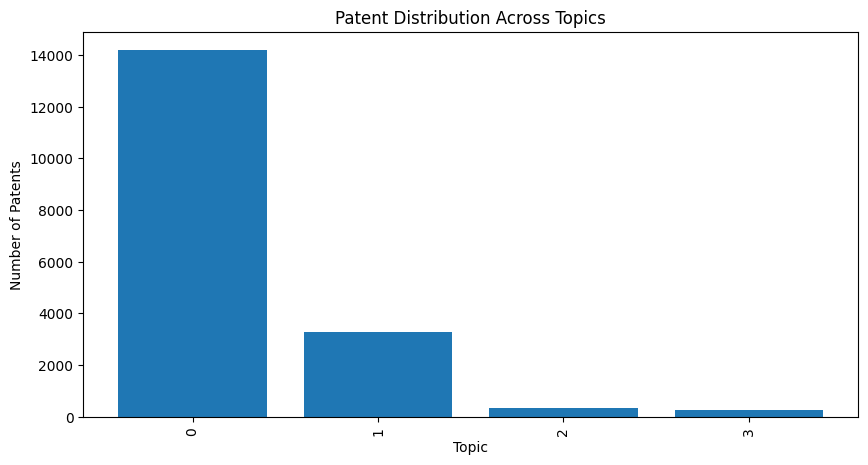

In [15]:
#Visualization
plt.figure(figsize=(10,5))


plt.bar(
    topic_distribution["topic"].astype(str),
    topic_distribution["patent_count"]
)


plt.xlabel("Topic")

plt.ylabel("Number of Patents")


plt.title(
    "Patent Distribution Across Topics"
)


plt.xticks(rotation=90)

plt.show()

In [16]:
#Step 5: Topic Keywords Analysis
#Show keywords for every topic.
for topic_id in topic_summary["Topic"].head(10):

    if topic_id != -1:

        print("\nTopic:", topic_id)

        print(
            topic_model.get_topic(topic_id))


Topic: 0
[('the', np.float64(0.1159818560117526)), ('of', np.float64(0.0733867534993319)), ('and', np.float64(0.061922237539257505)), ('to', np.float64(0.05976176017137131)), ('is', np.float64(0.04279394167769794)), ('in', np.float64(0.03533966268895473)), ('data', np.float64(0.034796668439871954)), ('information', np.float64(0.03211600405382279)), ('for', np.float64(0.03152515838831426)), ('wherein', np.float64(0.029574985163320563))]

Topic: 1
[('of', np.float64(0.0818981914722552)), ('parts', np.float64(0.0748756790764955)), ('is', np.float64(0.06343808938640523)), ('and', np.float64(0.06215362081680782)), ('the', np.float64(0.05695464074143214)), ('in', np.float64(0.05048830650106336)), ('to', np.float64(0.03637843974546219)), ('powder', np.float64(0.03495305030754077)), ('that', np.float64(0.03272075208698901)), ('healthcare', np.float64(0.03015780072869313))]

Topic: 2
[('the', np.float64(0.13573118518067281)), ('of', np.float64(0.0822357022351888)), ('information', np.float64(0

In [17]:
#Step 6: Create Human Readable Topic Names
#BERTopic names are usually not meaningful.
#Create mapping:
topic_labels = {

0:"Wearable Medical Sensors",

1:"AI Medical Imaging",

2:"Surgical Robotics",

3:"Drug Delivery Systems",

4:"Implantable Devices"

}

In [22]:
merged_df["topic_name"] = (
    merged_df["topic"]
    .map(topic_labels)
)

In [23]:
#To Check:-
merged_df[
[
"title",
"topic",
"topic_name"
]
].head()

,title,topic,topic_name
0,"Methods and systems for receiving, mapping and...",0,Wearable Medical Sensors
1,Electrocardiogram interpretating system with u...,0,Wearable Medical Sensors
2,Method and device for automatically tracking u...,0,Wearable Medical Sensors
3,X-ray detector with independent sleepable proc...,2,Surgical Robotics
4,"A kind of MDT consultation of doctors method, ...",0,Wearable Medical Sensors


In [24]:
#Step 7: Top Patents Per Topic
#Example:
#Find patents in Wearable Sensors.
topic_id = 0


merged_df[merged_df["topic"]==topic_id][
[
"patent_id",
"title",
"assignee_en"
]
].head(10)

,patent_id,title,assignee_en
0,CN102708128A,"Methods and systems for receiving, mapping and...",General Electric Co
1,KR102798691B1,Electrocardiogram interpretating system with u...,주식회사 메디컬에이아이
2,US11913937B2,Method and device for automatically tracking u...,Shanghai Kohler Electronics Ltd
4,CN108538402A,"A kind of MDT consultation of doctors method, ...",Shenzhen Zero One Cloud Medical Science And Te...
5,CN112908445A,Diabetes patient blood sugar management method...,Shanghai Fourth People's Hospital
6,CN108766540A,A kind of intelligent medical treatment system,Individual
7,KR102851115B1,robot,프랜카 에미카 게엠바하
8,US20180177426A1,Device Based on Virtual Reality Interactive Te...,South China University of Technology SCUT
9,CN109545394B,Interrogation method and device,Shanghai Yizhi Medical Technology Co ltd
10,US20180268109A1,Medical kiosk system and method,Individual


In [27]:
#Function 
def show_topic_patents(topic_id, n=10):

    return merged_df[
        merged_df["topic"]==topic_id
    ][
        [
        "patent_id",
        "title",
        "assignee_en"
        ]
    ].head(n)

In [28]:
#Use
show_topic_patents(0)

,patent_id,title,assignee_en
0,CN102708128A,"Methods and systems for receiving, mapping and...",General Electric Co
1,KR102798691B1,Electrocardiogram interpretating system with u...,주식회사 메디컬에이아이
2,US11913937B2,Method and device for automatically tracking u...,Shanghai Kohler Electronics Ltd
4,CN108538402A,"A kind of MDT consultation of doctors method, ...",Shenzhen Zero One Cloud Medical Science And Te...
5,CN112908445A,Diabetes patient blood sugar management method...,Shanghai Fourth People's Hospital
6,CN108766540A,A kind of intelligent medical treatment system,Individual
7,KR102851115B1,robot,프랜카 에미카 게엠바하
8,US20180177426A1,Device Based on Virtual Reality Interactive Te...,South China University of Technology SCUT
9,CN109545394B,Interrogation method and device,Shanghai Yizhi Medical Technology Co ltd
10,US20180268109A1,Medical kiosk system and method,Individual


In [30]:
#Step 8: Topic Evolution Over Time
#Important for innovation intelligence.
#Filing trend by topic
topic_year = (
    merged_df[merged_df["topic"]!=-1]
    .groupby(
        [
            "filing_year",
            "topic"
        ]
    )
    .size()
    .reset_index(
        name="patent_count"
    )
)


topic_year.head()

,filing_year,topic,patent_count
0,1993.0,0,1
1,1994.0,0,1
2,1995.0,0,2
3,1995.0,1,1
4,1998.0,0,1


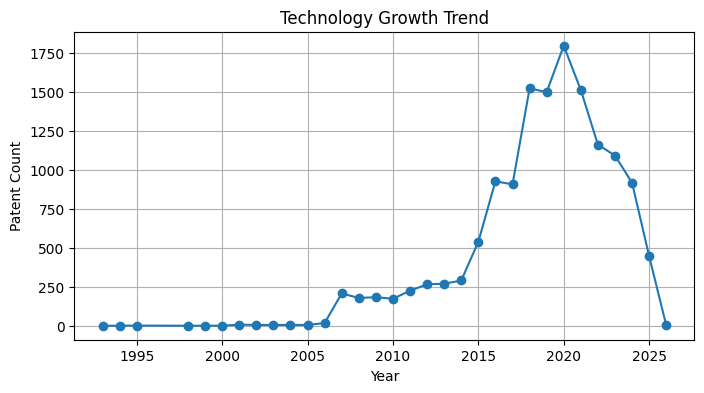

In [31]:
#Example:-
#Plot one topic:
topic_id = 0


trend = topic_year[
    topic_year["topic"]==topic_id
]


plt.figure(figsize=(8,4))


plt.plot(
    trend["filing_year"],
    trend["patent_count"],
    marker="o"
)


plt.xlabel("Year")

plt.ylabel("Patent Count")

plt.title(
    "Technology Growth Trend"
)


plt.grid()

plt.show()

In [33]:
#Step 9: Country-wise Topic Analysis
#Question:
#Which countries dominate each technology?
country_topic = pd.crosstab(
    merged_df["country"],
    merged_df["topic"]
)


country_topic.head()

topic,-1,0,1,2,3
country,,,,,
AR,0,1,0,0,0
AT,0,3,0,0,0
AU,0,133,10,0,0
BE,0,1,0,0,0
BR,0,39,2,0,0


In [29]:
#Top countries for Topic 0:
country_topic[0].sort_values(
    ascending=False
).head(10)

country
CN    6036
US    3602
KR    2014
WO    1235
EP     357
JP     232
CA     152
TW     151
AU     133
RU      66
Name: 0, dtype: int64

In [34]:
#Step 10: Assignee Analysis
#Question:
#Which companies are leading each innovation area?
assignee_topic = pd.crosstab(
    merged_df["assignee_en"],
    merged_df["topic"]
)

In [35]:
#Example:-
#For AI diagnostics:
assignee_topic[1].sort_values(
    ascending=False
).head(10)

assignee_en
Individual                                                 1265
Qingdao Jiarui Biological Technology Co Ltd                  35
Fujian Agriculture and Forestry University                   17
HEFEI ZHUGUANG GRAIN AND OIL TRADE Co Ltd                    17
BEIJING KEWEIHUA FOOD ENGINEERING AND TECHNOLOGY Co Ltd      14
Wuhe Tongshifu Food Co Ltd                                   12
Anhui Yanzhifang Food Co Ltd                                 10
ANHUI JINHE GRAIN & OIL GROUP Co Ltd                          9
Guangxi University                                            9
BY Health Co Ltd                                              9
Name: 1, dtype: int64

In [36]:
#Step 11: Topic + Citation Analysis
#Combine with your citation module.
topic_influence = (
    merged_df.groupby("topic")
    [
    "citation_influence_score"
    ]
    .mean()
    .sort_values(
        ascending=False
    )
)


topic_influence


topic
 1    0.085270
-1    0.056567
 3    0.055163
 0    0.051499
 2    0.051479
Name: citation_influence_score, dtype: float64